In [1]:
import os
import numpy as np
import pandas as pd
import re
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from sklearn.linear_model import LinearRegression
import csv

os.chdir('../../rf1-sra/stimuli/Scan-Card_Guessing_Game')
#Make a list of all the SR Files
SR_flist=[os.path.join(root, f) for root, dirs, files in os.walk('logs') for f in files if 'SR-Rating' in f]
SR_flist
#Make a list of Dataframes
ratings_list=[]
for f in SR_flist:
    sub=re.search('sub(.*)_',f).group(1)
    if any(i.isdigit() for i in sub):
        tmp_df=pd.read_csv(f)
        tmp_df['sub']=sub
        ratings_list.append(tmp_df)
#Concatonate the DataFrames together
srpr_df=pd.concat(ratings_list)
srpr_df=srpr_df.reset_index(drop=True)
srpr_df['Rating'].astype(int)
srpr_df

,TrialNumber,Partner,Trait,ran,order,Rating,sub
0,1,3,0,1.0,0.0,-2.0,1001
1,2,2,0,1.0,1.0,2.0,1001
2,3,1,0,1.0,2.0,2.0,1001
3,4,3,1,1.0,3.0,-2.0,1001
4,5,2,1,1.0,4.0,2.0,1001
...,...,...,...,...,...,...,...
409,2,2,0,1.0,1.0,-2.0,2002
410,3,1,0,1.0,2.0,-1.0,2002
411,4,3,1,1.0,3.0,0.0,2002
412,5,2,1,1.0,4.0,0.0,2002


In [2]:
demo = pd.read_csv('logs/AgeGender_230403.csv')
demo['sub']=demo['sub'].astype(int)
srpr_df['sub']=srpr_df['sub'].astype(int)
newsubs=[10317,10369,10402,10418,10486,10529,10541,10572,10581,10585,10589,10590,10596,10606,10608,10636,10638,10640,10642,10644,10647,10649,10652,10656,10657,10659,10663,10673,10674,10677,10685,10691,10700,10701,10716,10718,10720,10748,10767,10770,10774,10777,10781,10783,10785,10794,10800,10801,10802,10804,10806,10807,10812]
#full_df = pd.merge(srpr_df, demo, on = 'sub', how = 'right')
#full_df_dropped=full_df[full_df['sub'].isin(list(newsubs))]
#full_df = full_df_dropped
#full_df

srpr_df_dropped=srpr_df[srpr_df['sub'].isin(list(newsubs))]
srpr_df = srpr_df_dropped
srpr_df.to_csv('srpr.csv', index = False)


C:\Users\tup54227\AppData\Local\Temp\ipykernel_14948\1192450046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  srpr_df['partner']=srpr_df['Partner'].map(partner)
C:\Users\tup54227\AppData\Local\Temp\ipykernel_14948\1192450046.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  srpr_df['Outcome']=srpr_df['Trait'].map(Trait)


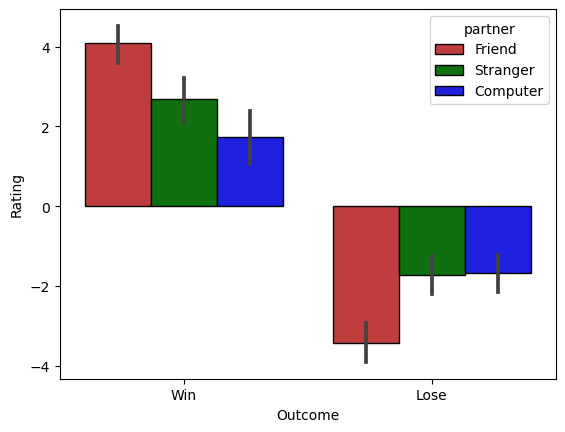

In [30]:
Trait = {0:'Win', 1:'Lose'}
partner = {3:'Friend',2:'Stranger',1:'Computer'}
srpr_df['partner']=srpr_df['Partner'].map(partner)
srpr_df['Outcome']=srpr_df['Trait'].map(Trait)
srpr_df
fig = sns.barplot(y='Rating',x='Outcome',hue='partner', data=srpr_df, palette=['tab:red','green','blue'], edgecolor='black', linewidth = 1)
plt.savefig('../../../rf1-sra-sharedreward/derivatives/SR_partner_ratings_anova.svg')
plt.show()

In [5]:
#srpr_df['sub'].unique()
srpr_df

,TrialNumber,Partner,Trait,ran,order,Rating,sub,partner,Outcome
12,1,3,0,1.0,0.0,5.0,10317,Friend,Win
13,2,2,0,1.0,1.0,4.0,10317,Stranger,Win
14,3,1,0,1.0,2.0,0.0,10317,Computer,Win
15,4,3,1,1.0,3.0,-2.0,10317,Friend,Lose
16,5,2,1,1.0,4.0,-1.0,10317,Stranger,Lose
...,...,...,...,...,...,...,...,...,...
397,2,2,0,1.0,1.0,5.0,10812,Stranger,Win
398,3,1,0,1.0,2.0,5.0,10812,Computer,Win
399,4,3,1,1.0,3.0,-5.0,10812,Friend,Lose
400,5,2,1,1.0,4.0,-5.0,10812,Stranger,Lose


In [6]:
#This loop collapses the 6 rows of Shared Reward Partner Ratings into 1 row for each participant
collapsed = {}
for index, row in srpr_df.iterrows():
    if(not row['sub'] in collapsed):
        collapsed[row['sub']] = {}
    column_name = Trait[row['Trait']] + '-' + partner[row['Partner']]
    collapsed[row['sub']][column_name] = row['Rating']
#PR = Partner Ratings from post-scan task
PR = pd.DataFrame(collapsed).T
PR = PR.reset_index().rename(columns = {'index':'sub'})
PR

,sub,Win-Friend,Win-Stranger,Win-Computer,Lose-Friend,Lose-Stranger,Lose-Computer
0,10317,5.0,4.0,0.0,-2.0,-1.0,0.0
1,10369,5.0,4.0,4.0,-5.0,-2.0,-2.0
2,10402,5.0,5.0,3.0,-5.0,-5.0,-5.0
3,10486,5.0,5.0,4.0,-5.0,-2.0,-2.0
4,10529,5.0,5.0,5.0,-5.0,-4.0,-3.0
5,10541,5.0,4.0,5.0,-2.0,0.0,0.0
6,10572,5.0,5.0,3.0,-2.0,-2.0,0.0
7,10585,5.0,5.0,3.0,-3.0,-3.0,-2.0
8,10589,4.0,1.0,1.0,-4.0,-3.0,-3.0
9,10590,5.0,3.0,-3.0,-4.0,-2.0,0.0


In [7]:
rating_diff = PR
rating_diff['win-diff-FC'] = rating_diff['Win-Friend'] - rating_diff['Win-Computer']
rating_diff['win-diff-FS'] = rating_diff['Win-Friend'] - rating_diff['Win-Computer']
rating_diff['lose-diff-FC'] = rating_diff['Lose-Friend'] - rating_diff['Lose-Computer']
rating_diff['lose-diff-FS'] = rating_diff['Lose-Friend'] - rating_diff['Lose-Computer']
rating_diff['win-lose-diff-FS'] = rating_diff['win-diff-FS'] - rating_diff['lose-diff-FS']
rating_diff['win-lose-diff-FC'] = rating_diff['win-diff-FC'] - rating_diff['lose-diff-FC']
rating_diff['sub'] = rating_diff['sub'].astype(int)
#demo['sub'] = demo['sub'].astype(int)
#rating_diff = rating_diff.merge(demo, on = 'sub', how = 'left')
#PR = rating_diff

In [13]:
srpr_df.to_csv('../../../rf1-sra-sharedreward/derivatives/partner_ratings_longformat.csv', index = False)
rating_diff.to_csv('../../../rf1-sra-sharedreward/derivatives/partner_ratings_wideformat.csv', index=False)

In [5]:
# Survey Data from REDCap (***need to fix file paths once it has final resting place)

In [8]:
pd.set_option('display.max_columns', None)
REDCAP_df = REDCAP_df.rename(columns={'Subject ID' : 'sub'})
REDCAP_df['sub'] = REDCAP_df['sub'].astype(int)
behav_df = pd.merge(REDCAP_df,PR, left_on = ['sub','Gender','Age'], right_on = ['sub','Gender','Age'], how = 'right')

behav_df['ios_F_S'] = behav_df['IOS friend'] - behav_df['IOS stranger']
behav_df['ios_F_C'] = behav_df['IOS friend'] - behav_df['IOS computer']
behav_df

plt_df = df_ios[['Subject', 'ios_p', 'ios_fu_score','ios_computer']].copy()
plt_df.columns = ['Subject', 'Friend', 'Stranger', 'Computer']
plt_df = plt_df.melt(id_vars=['Subject'], value_vars=['Friend', 'Stranger', 'Computer'], var_name='Partner', value_name='Closeness')
fig_closeness = sns.barplot(x = 'Partner', y = 'Closeness',data=plt_df, ci=68,
                            palette=['tab:blue','orangered','gold'], edgecolor='black', linewidth=2)
#plt.savefig('../../istart-sharedreward/derivatives/Figures/mean_closeness.svg')
plt.show()

plt_df_anova = AnovaRM(plt_df, 'Closeness', 'Subject', within=['Partner'])
plt_df_results = plt_df_anova.fit()
#print(plt_df_anova.anova_table["Pr > F"][0])

print(plt_df_results.anova_table)

NameError: name 'REDCAP_df' is not defined

,sub,Planfullness Total Score,scd_score_total,EROS Other Score,EROS Self Score,"NIH disadvantaged y/n Y=1, N=0",SUSD Mania Scale (sum),SUSD Depression Scale (sum),SOGS total score,TEI Subscale wellbeing,TEI Subscale selfcontrol,TEI Subscale emotionality,TEI Subscale sociability,TEI Total or global trait emotional intelligence,SCAARED - Total Score (Sum),SCAARED - Somatic/Panic/Agoraphibia Score (Sum),SCAARED - Generalized Anxiety Disorder Score (Sum),SCAARED - Separation Anxiety Disorder Score (Sum),SCAARED - Social Anxiety Disorder Score (Sum),AQ subscale Social Skill,AQ subscale Attention Switching,AQ subscale Attention to detail,AQ subscale Communication,AQ subscale Imagination,AQ Total,IOS stranger,IOS friend,IOS computer,PANAS Prescan Positive Total,PANAS Prescan Negative Total,NORC(NODS) lifetime total score,NORC(NODS) past year total score,MSPSS Retest Sum,MSPSS Friends Sub-Scale,MSPSS Family Sub-Scale,MSPSS Significant Other Sub-Scale,Sum Score NBS (Range from 1-5),BSMAS Total (sum),GS Total,Total Sum,GTI score,PANAS_Postscan Positive Total,PANAS Postscan Negative Total,CRT total score,Total Sum .1,CTQ-SF - Emotional Abuse Score,CTQ-SF - Emotional Abuse Score CUT OFF,CTQ-SF - Physical Abuse Score,CTQ-SF - Physical Abuse Score CUT OFF,CTQ-SF - Sexual Abuse Score,CTQ-SF - Sexual Abuse Score CUT OFF,CTQ-SF - Emotional Neglect Score,CTQ-SF - Emotional Neglect Score CUT OFF,CTQ-SF - Physical Neglect Score,CTQ-SF - Physical Neglect Score CUT OFF,"CTQ-SF Q10, revised (for Minimzation/Denial Score)","CTQ-SF Q16, revised (for Minimzation/Denial Score)","CTQ-SF Q22, revised (for Minimzation/Denial Score)",CTQ-SF - Minimization/Denial Score,CTQ-SF Total Score (Sum),CTQ-SF Total Score (Sum) - CUTOFF,Parental monitoring and involvement (Sum),Parental predictability (Sum),Parental environment (Sum),Physical environment (Sum),Safety and security (Sum),Overall - Sum of all subscales.,Age,Win-Friend,Win-Stranger,Win-Computer,Lose-Friend,Lose-Stranger,Lose-Computer,win-diff-FC,win-diff-FS,lose-diff-FC,lose-diff-FS,ios_F_S,ios_F_C
sub,1.000000,-0.475436,0.883149,-0.608282,-0.722691,-0.330324,0.289639,0.320201,-0.379474,0.268995,0.181607,-0.236940,-0.474508,-0.024743,0.737989,0.664085,0.557054,0.820992,0.503359,NaN,NaN,NaN,NaN,NaN,NaN,0.330324,0.211844,NaN,0.121236,0.515241,0.018207,NaN,NaN,NaN,NaN,NaN,0.509837,0.131600,0.018261,-0.140062,NaN,-0.037536,0.304745,-0.344483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.257057,-0.498344,-0.543964,-0.449660,0.058538,0.230785,0.640826,0.143530,0.143530,-0.424334,-0.424334,0.015149,0.211844
Planfullness Total Score,-0.475436,1.000000,-0.556181,0.253502,0.946220,0.492862,-0.172754,-0.829618,0.379879,0.764976,0.828558,0.913278,0.260263,0.924812,-0.691476,-0.568442,-0.827994,-0.276588,-0.360800,NaN,NaN,NaN,NaN,NaN,NaN,-0.883128,-0.119758,NaN,0.425755,-0.949226,0.323881,NaN,NaN,NaN,NaN,NaN,-0.786267,-0.923780,0.323736,-0.132176,NaN,0.568409,-0.150222,0.149821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.556300,0.883128,0.852067,0.323263,0.291558,0.377804,-0.220467,-0.169333,-0.169333,0.279214,0.279214,0.377725,-0.119758
scd_score_total,0.883149,-0.556181,1.000000,-0.747371,-0.718453,-0.668163,0.297564,0.528788,-0.265090,0.202807,0.137529,-0.313175,-0.339534,-0.041690,0.823642,0.869515,0.649871,0.767871,0.437150,NaN,NaN,NaN,NaN,NaN,NaN,0.231047,0.238581,NaN,0.003001,0.530390,-0.031223,NaN,NaN,NaN,NaN,NaN,0.421826,0.282098,-0.031184,-0.199052,NaN,-0.016601,0.576646,-0.536872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.554178,-0.231047,-0.780008,-0.058893,-0.534612,-0.189359,0.778931,0.017639,0.017639,-0.716295,-0.716295,0.095255,0.238581
EROS Other Score,-0.608282,0.253502,-0.747371,1.000000,0.403113,0.331371,-0.419816,-0.557783,0.636093,-0.076128,-0.167803,0.105957,0.436451,0.012525,-0.749160,-0.921820,-0.667960,-0.372306,-0.286445,NaN,NaN,NaN,NaN,NaN,Na

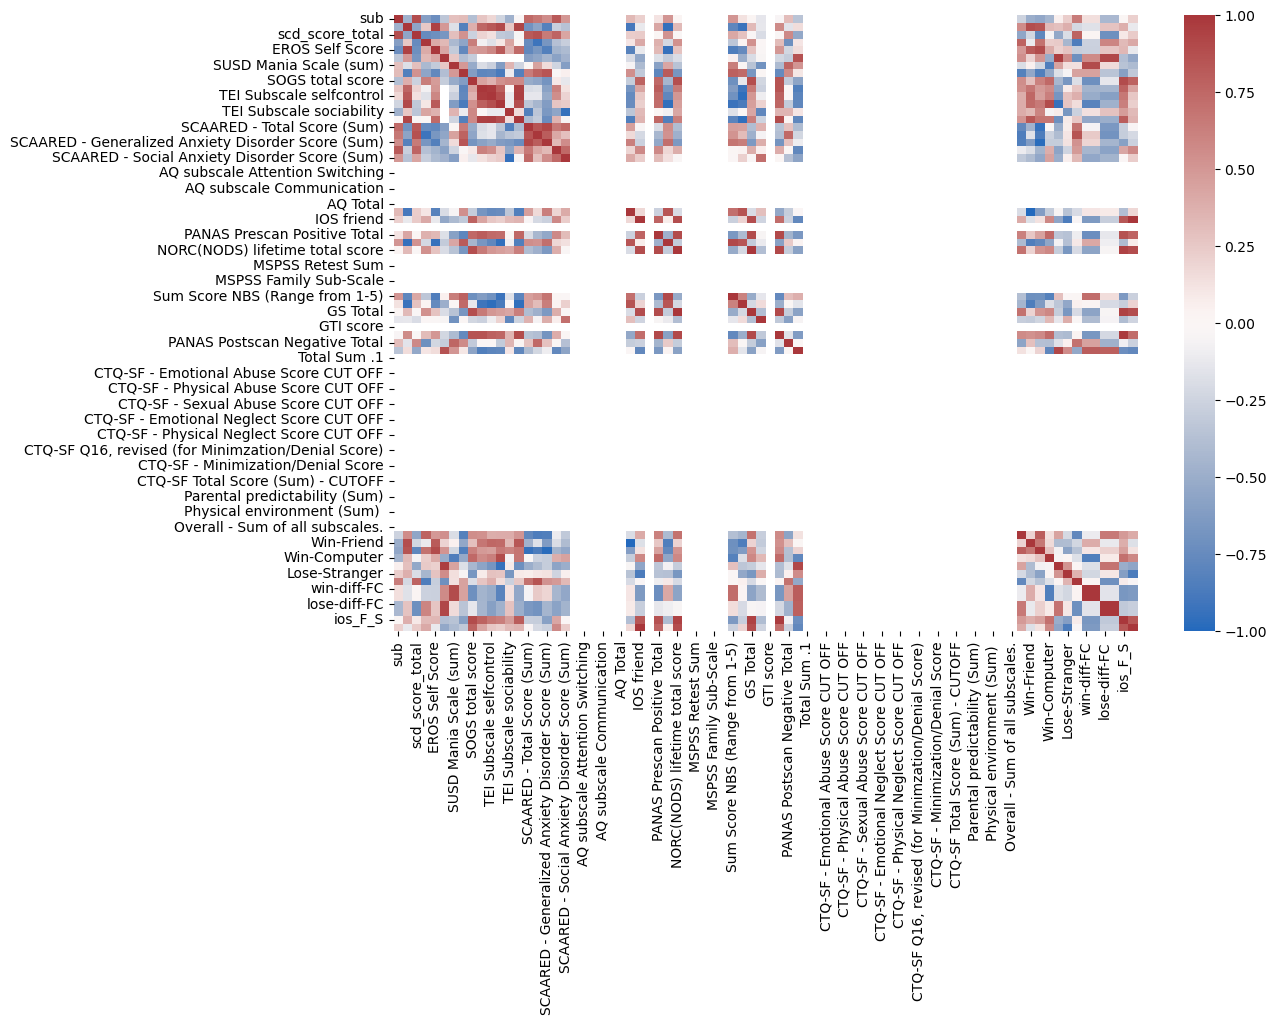

In [14]:
cormat=behav_df.corr()
display(cormat)
fig = plt.figure(figsize=(12, 8))
sns.heatmap(cormat,cmap='vlag',vmin=-1)
plt.show()

Friend v Stranger closeness, correlated with Friend v Stranger post-scan win rating 
r: -0.6787815421934158 ; p: 0.09360894576865579


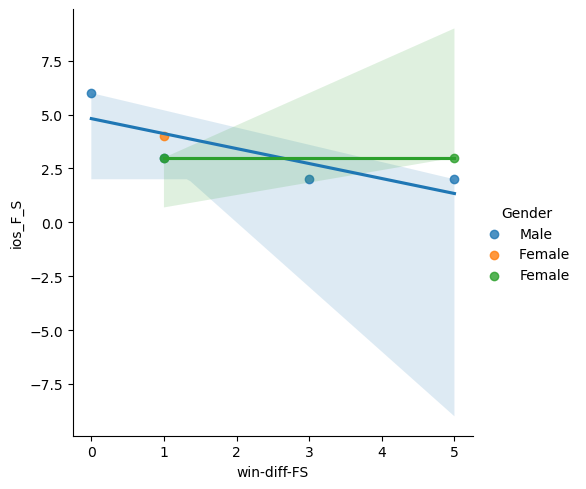

<class 'seaborn.axisgrid.FacetGrid'>


ValueError: x and y must have length at least 2.

In [85]:
ios_df = behav_df.dropna(subset=['ios_F_S'])

r,p = stats.pearsonr(ios_df['ios_F_S'], ios_df['win-diff-FS'])
print("Friend v Stranger closeness, correlated with Friend v Stranger post-scan win rating \nr: %s ; p: %s" %(r,p))
fig=sns.lmplot(y="ios_F_S",x="win-diff-FS", hue='Gender', data=ios_df, order=1)
plt.show()
print(type(fig))


GTI_df = behav_df.dropna(subset=['GTI score'])

r,p = stats.pearsonr(GTI_df['win-diff-FC'], GTI_df['GTI score'])
print("Friend v Computer post-scan win rating, correlated with generalized trust index total \nr: %s ; p: %s" %(r,p))
fig=sns.lmplot(y="win-diff-FC",x="GTI score", hue='Gender', data=GTI_df, order=1)
plt.show()
print(type(fig))

In [9]:
os.chdir('../../../rf1-sra-sharedreward/code')

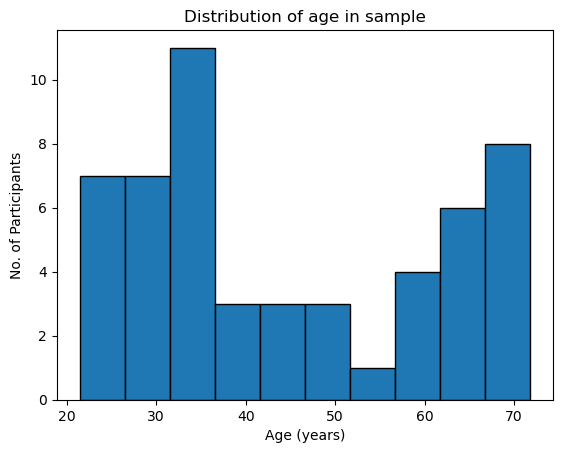

FileNotFoundError: [Errno 2] No such file or directory: '../../derivatives/age_hist.svg'

<Figure size 640x480 with 0 Axes>

In [35]:
df_age = pd.read_excel('../../rf1-sra-data/v2.3_SFN_Covariates.xlsx')
sublist  = pd.read_excel('sublist.xlsx')
df_trait = pd.merge(df_age, sublist, on = 'sub', how = 'right')
#df_trait.to_csv('../derivatives/df_trait.csv', index = False)
plt.hist(df_trait['sub_age'], edgecolor='k')
plt.title('Distribution of age in sample')
plt.xlabel('Age (years)')
plt.ylabel('No. of Participants')
plt.show()
plt.savefig('../../derivatives/age_hist.svg')

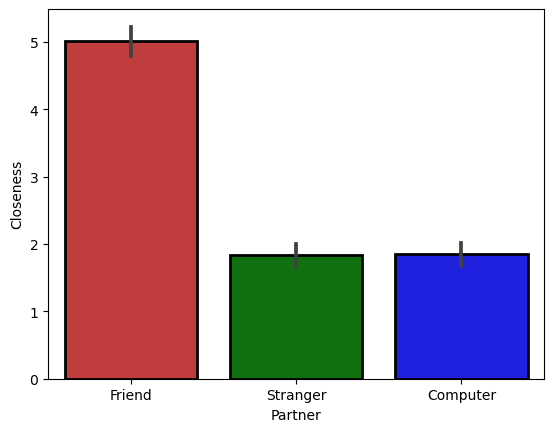

            F Value  Num DF  Den DF        Pr > F
Partner  103.067086     2.0   104.0  2.114236e-25


In [37]:
pd.set_option('display.max_columns', None)

plt_df = df_trait[['sub', 'ios_friend_score', 'ios_stranger_score','ios_computer_score']].copy()
plt_df.columns = ['Subject', 'Friend', 'Stranger', 'Computer']
plt_df = plt_df.melt(id_vars=['Subject'], value_vars=['Friend', 'Stranger', 'Computer'], var_name='Partner', value_name='Closeness')
fig_closeness = sns.barplot(x = 'Partner', y = 'Closeness',data=plt_df, ci=68,
                            palette=['tab:red','green','blue'], edgecolor='black', linewidth=2)
plt.savefig('../derivatives/mean_closeness.svg')
plt.show()

plt_df_anova = AnovaRM(plt_df, 'Closeness', 'Subject', within=['Partner'])
plt_df_results = plt_df_anova.fit()
#print(plt_df_anova.anova_table["Pr > F"][0])

print(plt_df_results.anova_table)

In [33]:
df_traits = pd.read_csv('../derivatives/df_trait.csv')
df_traits_2 = pd.merge(rating_diff, df_traits, on = 'sub', how = 'right')

df_behavior_sfn.to_csv('../derivatives/df_behavior_sfn.csv', index = False)